Imports and Initialization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import random

In [3]:
import kagglehub

In [4]:
np.random.seed(0)
random.seed(0)

In [5]:
path = kagglehub.dataset_download("tarkkaanko/amazon")

In [6]:
df = pd.read_csv(path+'/amazon_reviews.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB


In [8]:
df.drop({'Unnamed: 0'},axis=1, inplace=True)

In [9]:
df.reviewTime = pd.to_datetime(df.reviewTime)
df['year'] = df['reviewTime'].dt.year
df['month'] = df['reviewTime'].dt.month

In [10]:
df.isnull().sum()

reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
year                    0
month                   0
dtype: int64

In [11]:
df[df.duplicated]

,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound,year,month


In [12]:
df.head(5)

,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound,year,month
0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0,2014,7
1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0,2013,10
2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0,2012,12
3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0,2013,11
4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0,2013,7


In [13]:
df.dropna(subset='reviewText',inplace=True)

Task 1: Sentiment Analysis

In [14]:
A = df.copy()

In [15]:
A['overall'] = A['overall'].map({1:'negative', 2:'negative', 3:'neutral', 4:'positive', 5:'positive'})
A.head(5)

,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound,year,month
0,NaN,positive,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0,2014,7
1,0mie,positive,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0,2013,10
2,1K3,positive,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0,2012,12
3,1m2,positive,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0,2013,11
4,2&amp;1/2Men,positive,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0,2013,7


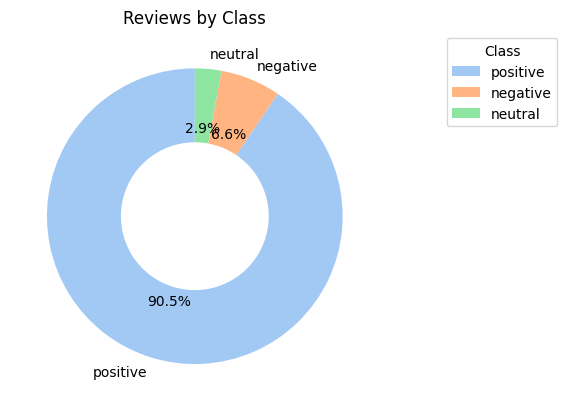

In [16]:
labels_class = (A['overall'].value_counts()).index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    A['overall'].value_counts(),
    labels=labels_class,
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_class, title="Class", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Reviews by Class')
plt.show()


In [17]:
A.columns

Index(['reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff',
       'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff',
       'score_average_rating', 'wilson_lower_bound', 'year', 'month'],
      dtype='object')

In [18]:
A.drop({'reviewerName', 'reviewTime', 'day_diff', 'total_vote', 'score_average_rating', 'wilson_lower_bound',
       'helpful_yes', 'helpful_no', 'score_pos_neg_diff', 'year', 'month'},axis=1,inplace=True)

In [19]:
A.head(5)

,overall,reviewText
0,positive,No issues.
1,positive,"Purchased this for my device, it worked as adv..."
2,positive,it works as expected. I should have sprung for...
3,positive,This think has worked out great.Had a diff. br...
4,positive,"Bought it with Retail Packaging, arrived legit..."


NLP Toolkit

In [20]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer,WordNetLemmatizer         # module for stemming
from nltk.tokenize import TweetTokenizer,sent_tokenize,word_tokenize   # module for tokenizing strings

import re                                  # library for regular expression operations
import string                              # for string operations

[nltk_data] Downloading package stopwords to
[nltk_data]     /usr/local/lib/python3.13/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /usr/local/lib/python3.13/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [21]:
# tweet preprocessing #
def preprocess_tweets(tweet):
    # cleans the tweet after removing extra stop words, punctuation etc. After this, the tweet needs to be tokenized, into words & then words converted into their respective lemma
    tweets_clean = []
    
    # Instantiate stemming class
    Lemma = WordNetLemmatizer()
    
    # Create an empty list to store the stems
    tweets_lemma = []

    stopwords_english = stopwords.words('english') 
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)
    
    tweet2 = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet2 = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet2)
    
    tweet2 = re.sub(r'#', '', tweet2)   # remove hashtags
    
    tweet2 = re.sub(r"@\w+","", tweet2)        # remove mentions
    

    tweet_tokens = tokenizer.tokenize(tweet2)
    
    for word_token in tweet_tokens:
        if(word_token not in stopwords_english and word_token not in string.punctuation):
            stem_word = Lemma.lemmatize(word_token)
            tweets_clean.append(stem_word)
    
    return tweets_clean

In [22]:
A.reviewText.apply(preprocess_tweets)

0                                                 [issue]
1       [purchased, device, worked, advertised, never,...
2       [work, expected, sprung, higher, capacity, thi...
3       [think, worked, great.had, diff, bran, 64gb, c...
4       [bought, retail, packaging, arrived, legit, or...
                              ...                        
4910    [bought, sandisk, 16gb, class, 10, use, htc, i...
4911    [used, extending, capability, samsung, galaxy,...
4912    [great, card, fast, reliable, come, optional, ...
4913    [good, amount, space, stuff, want, fit, gopro,...
4914    [heard, bad, thing, 64gb, micro, sd, card, cra...
Name: reviewText, Length: 4914, dtype: object

In [23]:
le = LabelEncoder()
A['overall'] = le.fit_transform(A['overall'])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(A.reviewText, A.overall,
    test_size=0.20,
    stratify=A['overall'],
    random_state=0
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [25]:
def build_freq(tweets,label):
    ys = label
    yslist = np.squeeze(ys).tolist()

    freq = {}

    for tweet,y in zip(tweets,ys):
        for word in preprocess_tweets(tweet):
            pair = (word,y)
            if pair in freq:
                freq[pair] += 1
            else:
                freq[pair] = 1
    return freq

freqs = build_freq(X_train, y_train)

In [26]:
def extract_feature_map_multiclass(tweet, freq, classes=[0,1,2]):
    clean_word = preprocess_tweets(tweet)
    x = np.zeros((1, len(classes) + 1))
    x[0, 0] = 1  # bias term
    for word in clean_word:
        for i, c in enumerate(classes):
            x[0, i+1] += freq.get((word, c), 0)
    return x

In [27]:
classes = [0, 1, 2]  

X = np.zeros((len(X_train), len(classes) + 1))
for i in range(len(X_train)):
    X[i] = extract_feature_map_multiclass(X_train[i], freqs, classes)
y = y_train

X_test_matrix = np.zeros((len(X_test), len(classes) + 1))
for i in range(len(X_test)):
    X_test_matrix[i] = extract_feature_map_multiclass(X_test[i], freqs, classes)

np.unique(y_train)

array([0, 1, 2])

Model 1: Naive Bayes

In [28]:
MB = MultinomialNB(alpha=1)
MB.fit(X,y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [29]:
Pred_y_nb = MB.predict(X_test_matrix)
y_pred_proba_nb = MB.predict_proba(X_test_matrix)

In [30]:
print(classification_report(y_test, Pred_y_nb,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.33      0.63      0.43        65
     neutral       0.03      0.18      0.06        28
    positive       0.97      0.78      0.86       890

    accuracy                           0.75       983
   macro avg       0.45      0.53      0.45       983
weighted avg       0.90      0.75      0.81       983



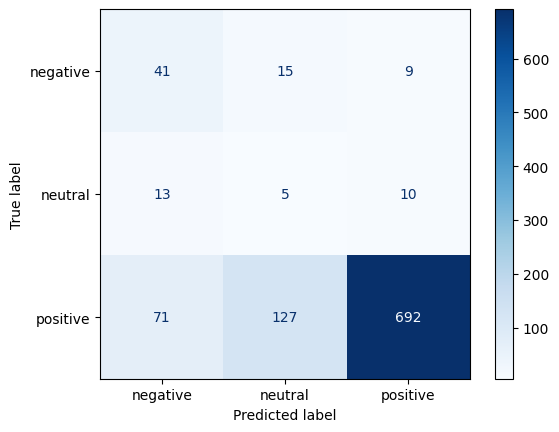

In [31]:
cm_nb = confusion_matrix(y_test, Pred_y_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 2: Random Forests

In [32]:
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators = 4000)
model_rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",4000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [33]:
Pred_y_rf = model_rf.predict(X_test_matrix)
y_pred_proba_rf = model_rf.predict_proba(X_test_matrix)

In [34]:
print(classification_report(y_test, Pred_y_rf,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.44      0.25      0.32        65
     neutral       0.00      0.00      0.00        28
    positive       0.93      0.98      0.95       890

    accuracy                           0.91       983
   macro avg       0.46      0.41      0.42       983
weighted avg       0.87      0.91      0.88       983



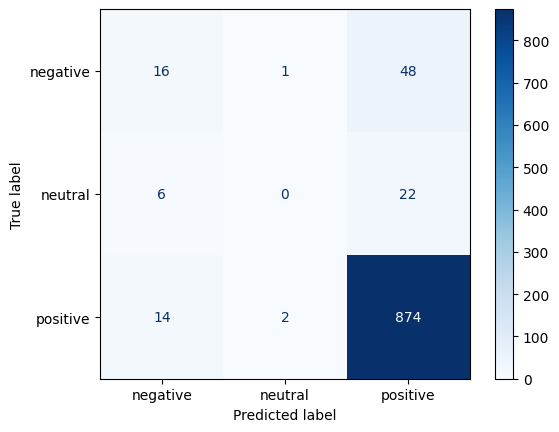

In [35]:
cm_rf = confusion_matrix(y_test, Pred_y_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 3: XGBoost

In [36]:
from xgboost import XGBClassifier

In [37]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_x = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1,
    eval_metric='mlogloss'   
)

model_x.fit(X, y, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [38]:
Pred_y_x = model_x.predict(X_test_matrix)
y_pred_proba_x = model_x.predict_proba(X_test_matrix)

In [39]:
print(classification_report(y_test, Pred_y_x,
      target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.29      0.74      0.41        65
     neutral       0.11      0.18      0.14        28
    positive       0.97      0.84      0.90       890

    accuracy                           0.81       983
   macro avg       0.45      0.58      0.48       983
weighted avg       0.90      0.81      0.84       983



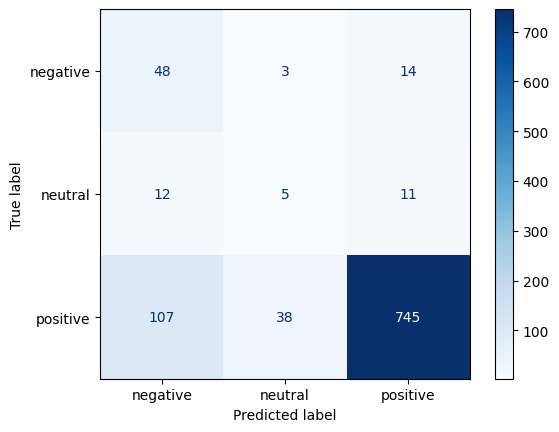

In [40]:
cm_x = confusion_matrix(y_test, Pred_y_x)
ConfusionMatrixDisplay(cm_x, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()

Model 4: Neural Net (Weighted vs Unweighted)

In [41]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(0)


In [42]:
def build_classifier():
    model = Sequential([
        Dense(128, activation='relu', input_shape=[X.shape[1]]),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [43]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(5.059202059202059), 1: np.float64(11.494152046783626), 2: np.float64(0.3682780588345512)}


In [44]:
model_nn = build_classifier()
print(model_nn.summary())

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971 (46.76 KB)

 Trainable params: 11,523 (45.01 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history = model_nn.fit(
    X, y,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
    class_weight = class_weights
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3702 - loss: 1.5824 - val_accuracy: 0.5438 - val_loss: 1.2083
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3985 - loss: 1.2747 - val_accuracy: 0.6671 - val_loss: 0.9816
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4307 - loss: 1.2479 - val_accuracy: 0.7421 - val_loss: 0.9116
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.4809 - loss: 1.2514 - val_accuracy: 0.6010 - val_loss: 1.0119
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.5130 - loss: 1.1809 - val_accuracy: 0.5286 - val_loss: 1.0993
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.5251 - loss: 1.1073 - val_accuracy: 0.3253 - val_loss: 1.1659
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.5127 - loss: 1.0791 - val_accuracy: 0.3266 - val_loss: 1.0248
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.5188 - loss: 1.0983 - val_accuracy: 

In [46]:
Pred_y_nn= model_nn.predict(X_test_matrix)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [47]:
pred_nn = np.argmax(Pred_y_nn, axis=1)

print(classification_report(y_test, pred_nn,  zero_division=0, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.42      0.58      0.49        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.95      0.95       890

    accuracy                           0.90       983
   macro avg       0.46      0.51      0.48       983
weighted avg       0.89      0.90      0.89       983



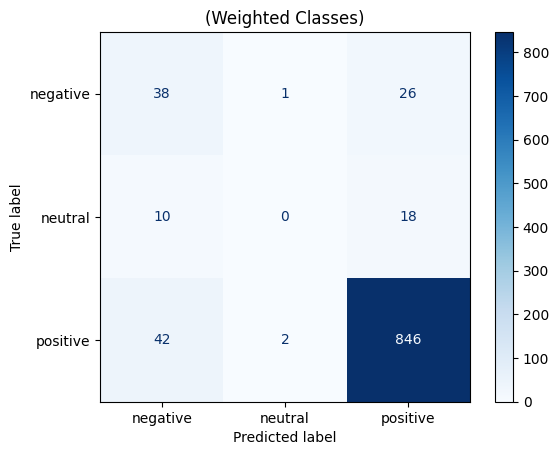

In [48]:
cmnn = confusion_matrix(y_test, pred_nn)
ConfusionMatrixDisplay(cmnn, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.title('(Weighted Classes)')
plt.show()


In [49]:
model_nn_now = build_classifier()
print(model_nn_now.summary())

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,971 (46.76 KB)

 Trainable params: 11,523 (45.01 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [50]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history_now = model_nn_now.fit(
    X, y,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5270 - loss: 1.2089 - val_accuracy: 0.8869 - val_loss: 0.7462
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7236 - loss: 0.8907 - val_accuracy: 0.9136 - val_loss: 0.5652
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.8244 - loss: 0.7036 - val_accuracy: 0.9212 - val_loss: 0.4463
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.8648 - loss: 0.5819 - val_accuracy: 0.9136 - val_loss: 0.3886
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.8830 - loss: 0.4742 - val_accuracy: 0.9288 - val_loss: 0.3539
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.8944 - loss: 0.4174 - val_accuracy: 0.9161 - val_loss: 0.3015
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.8979 - loss: 0.3884 - val_accuracy: 0.9123 - val_loss: 0.2843
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8979 - loss: 0.3708 - val_accuracy

In [51]:
Pred_y_nn= model_nn_now.predict(X_test_matrix)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [52]:
pred_nn_now = np.argmax(Pred_y_nn, axis=1)

print(classification_report(y_test, pred_nn_now,  zero_division=0, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.64      0.11      0.18        65
     neutral       0.00      0.00      0.00        28
    positive       0.91      1.00      0.95       890

    accuracy                           0.91       983
   macro avg       0.52      0.37      0.38       983
weighted avg       0.87      0.91      0.88       983



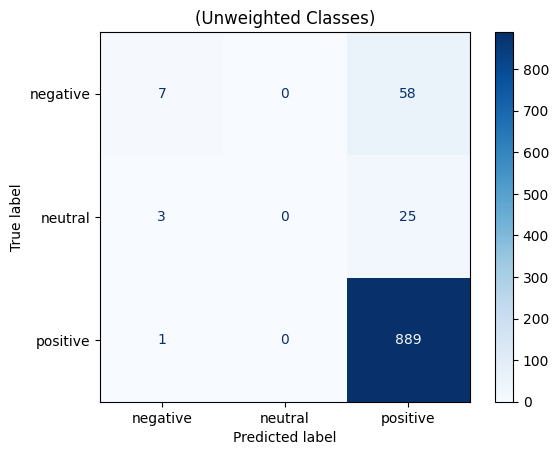

In [53]:
cmnn_now = confusion_matrix(y_test, pred_nn_now)
ConfusionMatrixDisplay(cmnn_now, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.title('(Unweighted Classes)')
plt.show()


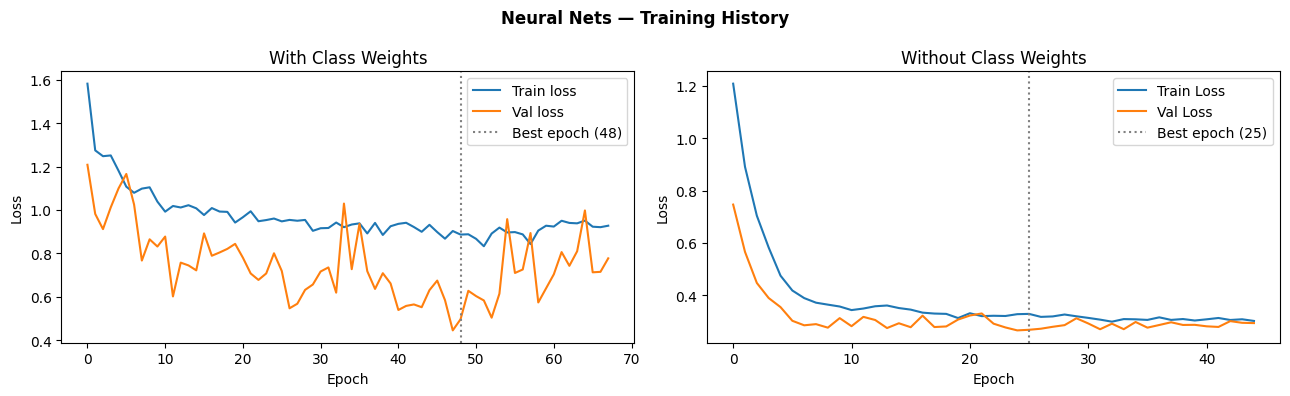

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(x=best_epoch, color='grey', linestyle=':', label=f'Best epoch ({best_epoch})')
axes[0].set_title('With Class Weights')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_now.history['loss'],     label='Train Loss')
axes[1].plot(history_now.history['val_loss'], label='Val Loss')
best_epoch_now = np.argmin(history_now.history['val_loss']) + 1
axes[1].axvline(x=best_epoch_now, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_now})')
axes[1].set_title('Without Class Weights')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Neural Nets — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

Model 5: LSTM (Weighted vs Unweighted)

In [55]:
from tensorflow.keras.layers import LSTM, Embedding, SpatialDropout1D

def build_lstm(vocab_size, embedding_dim=64, max_len=50):
    model = Sequential([
        # maps token integers to dense vectors
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        
        # sequence modelling
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        
        LSTM(64),
        Dropout(0.2),
        
        # classification head
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=50)

vocab_size = min(tokenizer.num_words, len(tokenizer.word_index) + 1)
model_lstm = build_lstm(vocab_size)
model_lstm.build(input_shape=(None, 50))  # None = batch size, 50 = max_len
print(model_lstm.summary())

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       504,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,235 (2.50 MB)

 Trainable params: 655,235 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

None


In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
    class_weight = class_weights
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7853 - loss: 1.0841 - val_accuracy: 0.7916 - val_loss: 0.8596
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8025 - loss: 0.8602 - val_accuracy: 0.6684 - val_loss: 0.8411
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8556 - loss: 0.6850 - val_accuracy: 0.8247 - val_loss: 0.4583
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8871 - loss: 0.5795 - val_accuracy: 0.7992 - val_loss: 0.5133
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9173 - loss: 0.4632 - val_accuracy: 0.8335 - val_loss: 0.4670
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9297 - loss: 0.2729 - val_accuracy: 0.8590 - val_loss: 0.4312
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9545 - loss: 0.1645 - val_accuracy: 0.8869 - val_loss: 0.4225
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9472 - loss: 0.1134 - val_accuracy: 0.

In [58]:
Pred_y_lstm= model_lstm.predict(X_test_seq)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [59]:
pred_nn_lstm = np.argmax(Pred_y_lstm, axis=1)

print(classification_report(y_test, pred_nn_lstm,  zero_division=0, target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.43      0.42      0.42        65
     neutral       0.14      0.29      0.19        28
    positive       0.96      0.93      0.94       890

    accuracy                           0.88       983
   macro avg       0.51      0.54      0.52       983
weighted avg       0.90      0.88      0.89       983



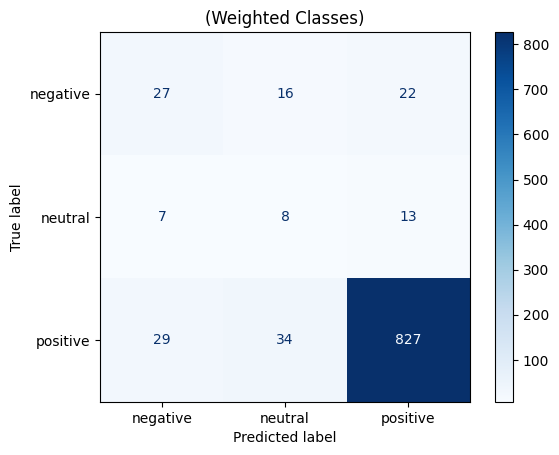

In [60]:
cmlstm = confusion_matrix(y_test, pred_nn_lstm)
ConfusionMatrixDisplay(cmlstm, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.title('(Weighted Classes)')
plt.show()


In [61]:
model_lstm_now = build_lstm(vocab_size)
model_lstm_now.build(input_shape=(None, 50))  # None = batch size, 50 = max_len
print(model_lstm_now.summary())

/usr/local/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       504,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,235 (2.50 MB)

 Trainable params: 655,235 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

None


In [62]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    mode='min',            
    restore_best_weights=True
)

history_lstm_now = model_lstm_now.fit(
    X_train_seq, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8919 - loss: 0.4806 - val_accuracy: 0.9111 - val_loss: 0.3589
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9036 - loss: 0.3831 - val_accuracy: 0.9111 - val_loss: 0.3583
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9036 - loss: 0.3827 - val_accuracy: 0.9111 - val_loss: 0.3584
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9036 - loss: 0.3799 - val_accuracy: 0.9111 - val_loss: 0.3573
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9036 - loss: 0.3698 - val_accuracy: 0.9111 - val_loss: 0.3561
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9036 - loss: 0.3078 - val_accuracy: 0.9111 - val_loss: 0.2982
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9253 - loss: 0.2200 - val_accuracy: 0.9263 - val_loss: 0.3021
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9434 - loss: 0.1765 - val_accuracy: 0.

In [63]:
Pred_y_lstm_now= model_lstm_now.predict(X_test_seq)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [64]:
pred_lstm_now = np.argmax(Pred_y_lstm_now, axis=1)

print(classification_report(y_test, pred_lstm_now, zero_division=0,target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.52      0.62      0.56        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.97      0.96       890

    accuracy                           0.92       983
   macro avg       0.49      0.53      0.51       983
weighted avg       0.90      0.92      0.91       983



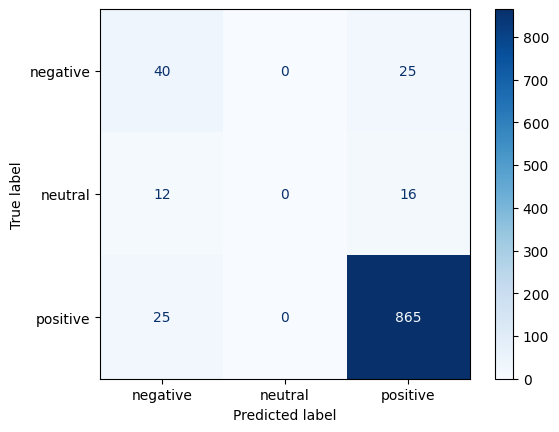

In [65]:
cmlstm_now = confusion_matrix(y_test, pred_lstm_now)
ConfusionMatrixDisplay(cmlstm_now, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


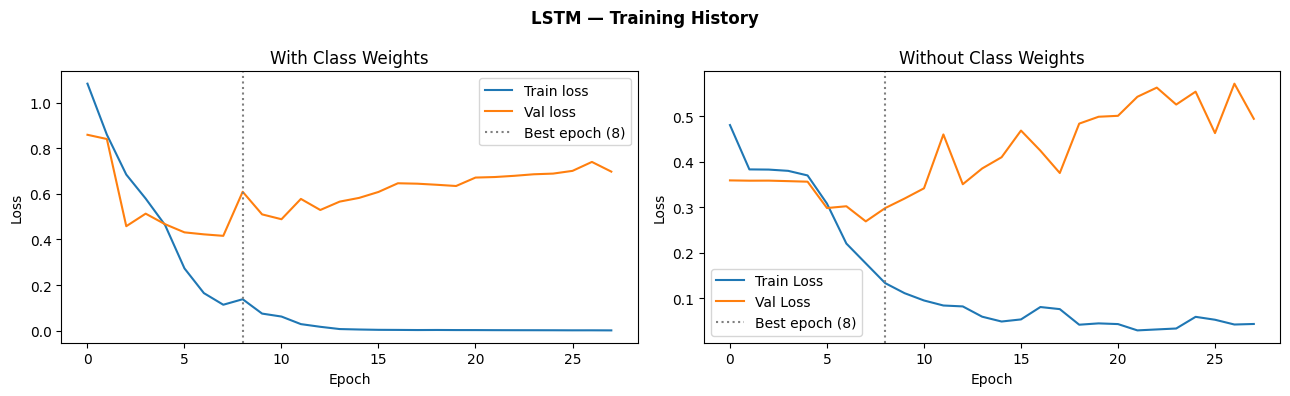

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_lstm.history['loss'],     label='Train loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val loss')
best_epoch_lstm = np.argmin(history_lstm.history['val_loss']) + 1
axes[0].axvline(x=best_epoch_lstm, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_lstm})')
axes[0].set_title('With Class Weights')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm_now.history['loss'],     label='Train Loss')
axes[1].plot(history_lstm_now.history['val_loss'], label='Val Loss')
best_epoch_lstm_now = np.argmin(history_lstm_now.history['val_loss']) + 1
axes[1].axvline(x=best_epoch_lstm_now, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_lstm_now})')
axes[1].set_title('Without Class Weights')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('LSTM — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

AUC-ROC Curves

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


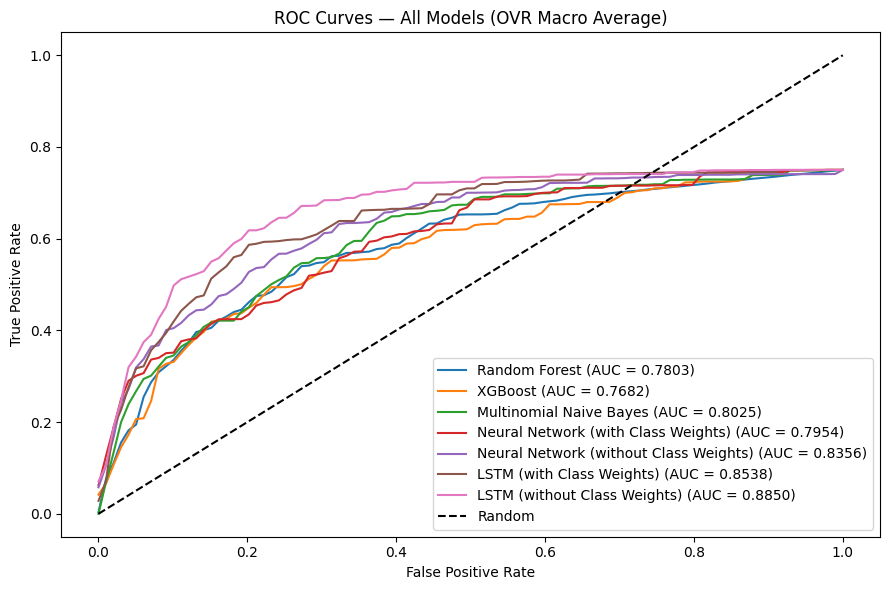

In [67]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0,1,2,3])

models = {
    'Random Forest':           (model_rf,   X_test_matrix),
    'XGBoost':                 (model_x,    X_test_matrix),
    'Multinomial Naive Bayes': (MB,          X_test_matrix),
    'Neural Network (with Class Weights)':          (model_nn,    X_test_matrix),
    'Neural Network (without Class Weights)':          (model_nn_now,    X_test_matrix),
    'LSTM (with Class Weights)':                    (model_lstm,  X_test_seq),
    'LSTM (without Class Weights)':                    (model_lstm_now,  X_test_seq)
}

plt.figure(figsize=(9, 6))

for name, (model, X_feat) in models.items():
    proba = model.predict(X_feat) if isinstance(model, tf.keras.Model) \
            else model.predict_proba(X_feat)
    auc = roc_auc_score(y_test, proba, multi_class='ovr')
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros(100)
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr /= 4
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (OVR Macro Average)')
plt.legend()
plt.tight_layout()
plt.show()

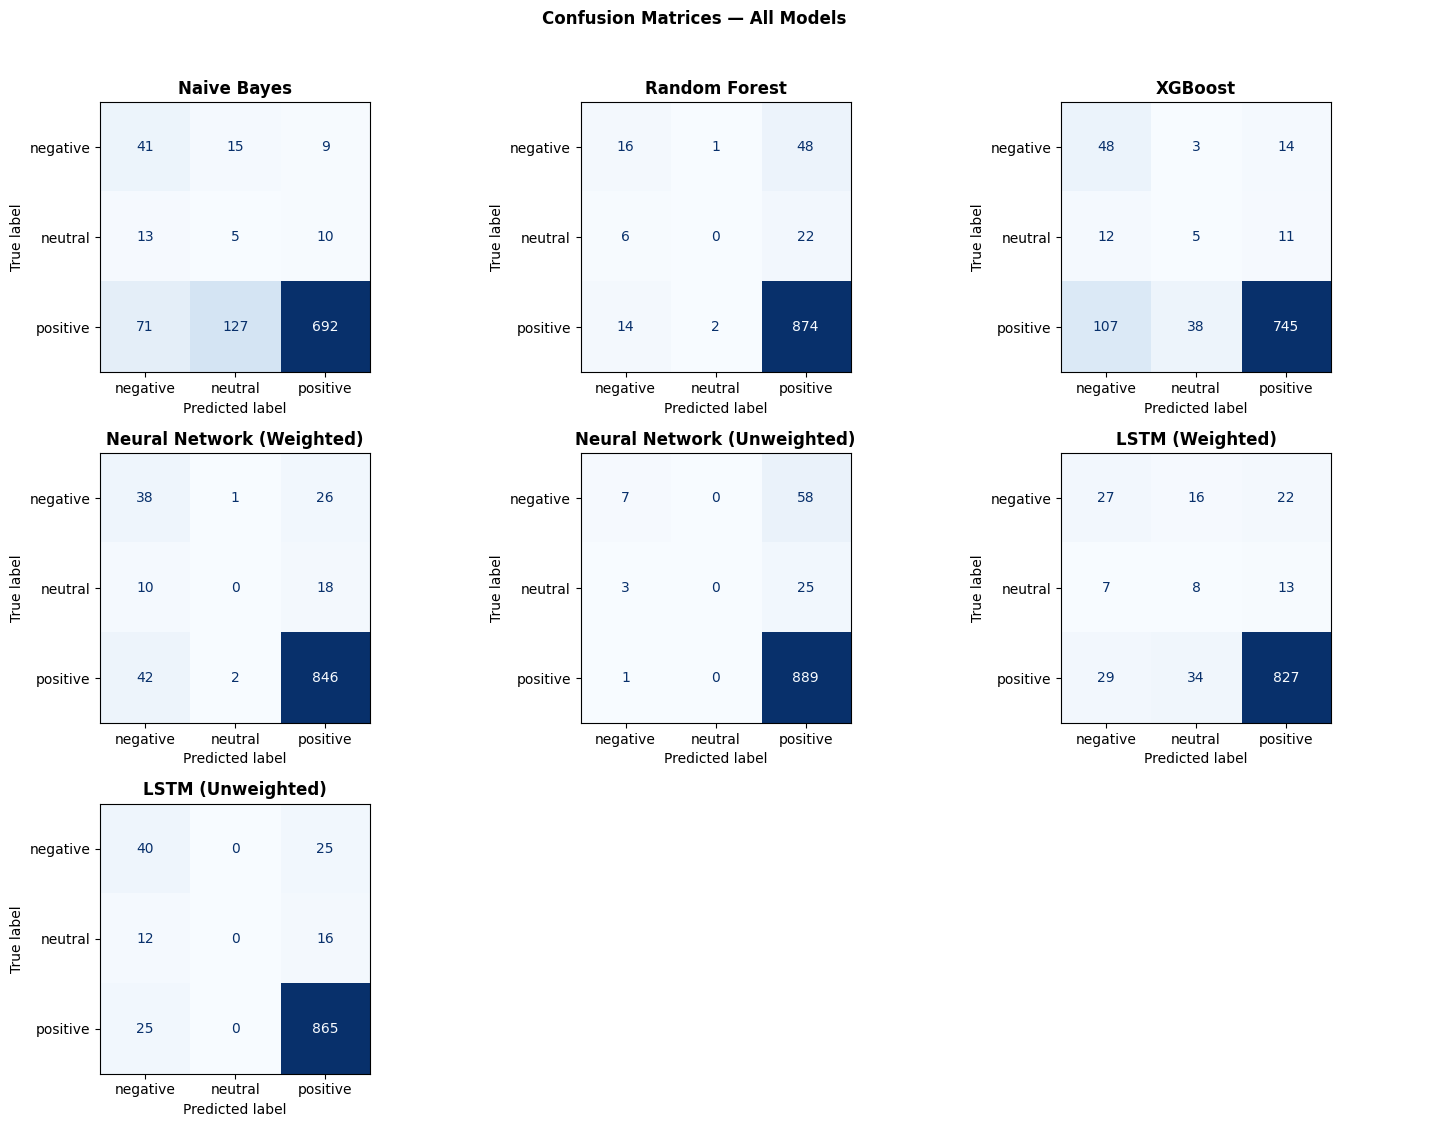

In [68]:
predictions = {
    'Naive Bayes':    Pred_y_nb,
    'Random Forest':  Pred_y_rf,
    'XGBoost':        Pred_y_x,
    'Neural Network (Weighted)': pred_nn,
    'Neural Network (Unweighted)': pred_nn_now,
    'LSTM (Weighted)':           pred_nn_lstm,
    'LSTM (Unweighted)': pred_lstm_now
}

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.astype(str)).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')

axes[-2].axis('off') 
axes[-1].axis('off') 
plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

DistilBERT for Sentiment Analysis

In [69]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

In [70]:
# 1. Tokeniser
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [71]:
# 2. Dataset class
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, maxlen=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=maxlen,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer)

In [72]:
# 3. Model — 3 classes
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [73]:
training_args = TrainingArguments(
    output_dir='./results',          # output directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=8,   # batch size per device during training
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [74]:
# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,1.187575
20,1.162327
30,1.120039
40,1.033544
50,0.893599
60,0.700842
70,0.505668
80,0.318600
90,0.209821
100,0.615530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1476, training_loss=0.26858714581303156, metrics={'train_runtime': 344.4968, 'train_samples_per_second': 34.233, 'train_steps_per_second': 4.285, 'total_flos': 390553972939008.0, 'train_loss': 0.26858714581303156, 'epoch': 3.0})

In [75]:
preds = trainer.predict(test_dataset)
y_pred_DBERT = np.argmax(preds.predictions, axis=1)

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [76]:

print(classification_report(y_test, y_pred_DBERT, zero_division=0,target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.64      0.72      0.68        65
     neutral       0.00      0.00      0.00        28
    positive       0.96      0.98      0.97       890

    accuracy                           0.94       983
   macro avg       0.53      0.57      0.55       983
weighted avg       0.91      0.94      0.92       983



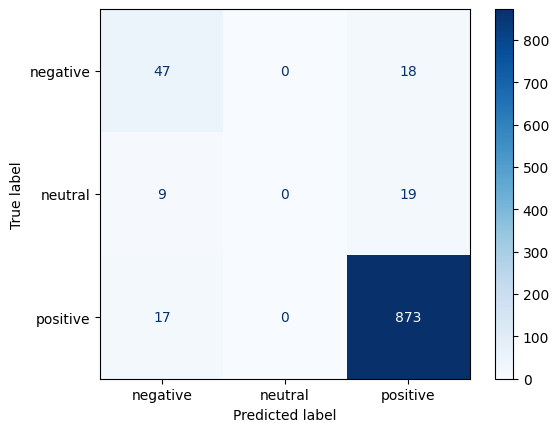

In [77]:
cmdbert = confusion_matrix(y_test, y_pred_DBERT)
ConfusionMatrixDisplay(cmdbert, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


In [78]:
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        
        # compute weights from training labels
        weights = torch.tensor([
            len(y_train) / (3 * (y_train == 0).sum()),
            len(y_train) / (3 * (y_train == 1).sum()),
            len(y_train) / (3 * (y_train == 2).sum()),
        ], dtype=torch.float).to(logits.device)
        
        loss_fn = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [79]:
trainer_w = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer_w.train()

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.649494
20,0.599204
30,0.975040
40,0.454732
50,0.311099
60,0.995772
70,0.925818
80,0.569889
90,0.276730
100,0.907406


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1476, training_loss=0.5438202817099003, metrics={'train_runtime': 367.728, 'train_samples_per_second': 32.07, 'train_steps_per_second': 4.014, 'total_flos': 390553972939008.0, 'train_loss': 0.5438202817099003, 'epoch': 3.0})

In [80]:
preds_w = trainer_w.predict(test_dataset)
y_pred_DBERT_w = np.argmax(preds_w.predictions, axis=1)

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [81]:

print(classification_report(y_test, y_pred_DBERT_w, zero_division=0,target_names=le.classes_.astype(str)))

              precision    recall  f1-score   support

    negative       0.80      0.68      0.73        65
     neutral       0.24      0.29      0.26        28
    positive       0.97      0.97      0.97       890

    accuracy                           0.93       983
   macro avg       0.67      0.64      0.65       983
weighted avg       0.93      0.93      0.93       983



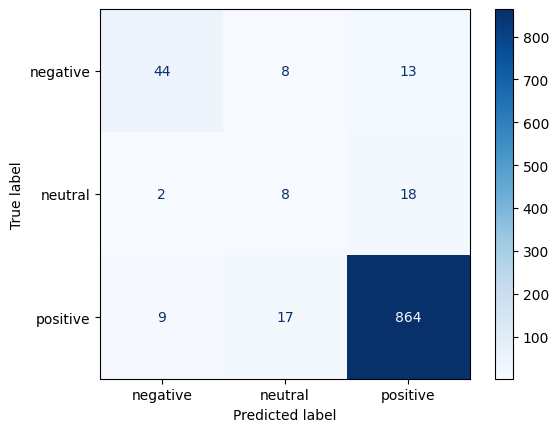

In [82]:
cmdbert_w = confusion_matrix(y_test, y_pred_DBERT_w)
ConfusionMatrixDisplay(cmdbert_w, display_labels=le.classes_.astype(str)).plot(cmap='Blues')
plt.show()


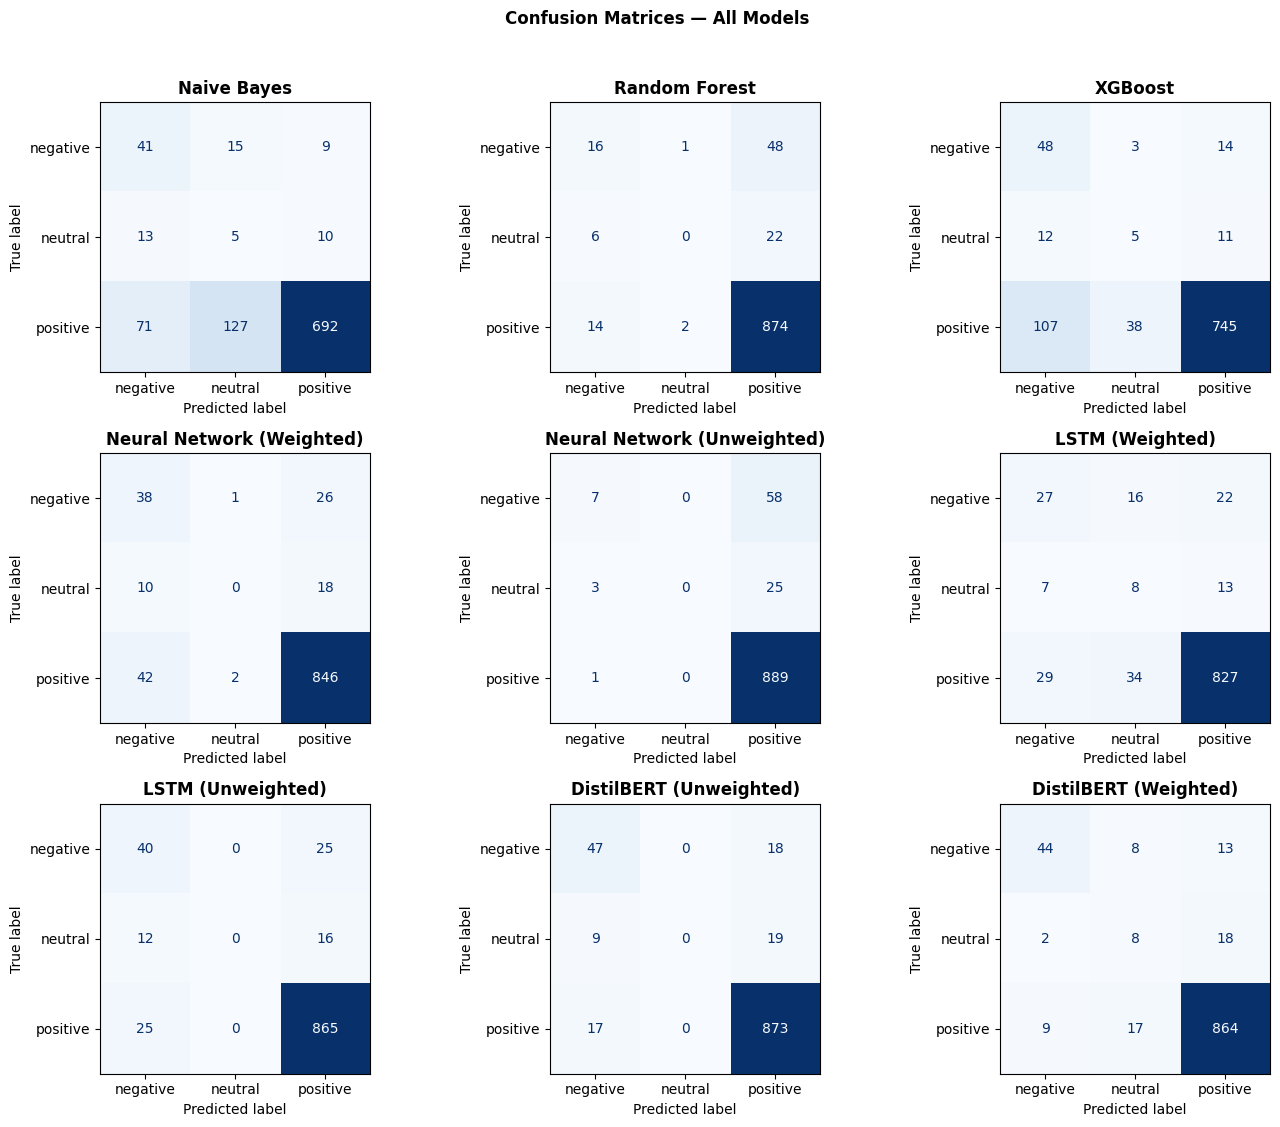

In [84]:
predictions = {
    'Naive Bayes':    Pred_y_nb,
    'Random Forest':  Pred_y_rf,
    'XGBoost':        Pred_y_x,
    'Neural Network (Weighted)': pred_nn,
    'Neural Network (Unweighted)': pred_nn_now,
    'LSTM (Weighted)':           pred_nn_lstm,
    'LSTM (Unweighted)': pred_lstm_now,
    'DistilBERT (Unweighted)' : y_pred_DBERT,
    'DistilBERT (Weighted)' : y_pred_DBERT_w,
}

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.astype(str)).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()